In [1]:
%pip install mediapipe==0.10.35 opencv-python==4.10.0.84 scipy numpy

Note: you may need to restart the kernel to use updated packages.


In [89]:
import cv2
import mediapipe as mp
import numpy as np
import math
import time
import os
import urllib.request
import winsound

from scipy.spatial import distance

from mediapipe.tasks import python as mp_tasks
from mediapipe.tasks.python import vision as mp_vision

In [90]:
print("OpenCV :", cv2.__version__)
print("MediaPipe :", mp.__version__)

OpenCV : 5.0.0
MediaPipe : 0.10.35


In [91]:
MODEL_PATH = "face_landmarker.task"
MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/face_landmarker/"
    "face_landmarker/float16/1/face_landmarker.task"
)

if not os.path.exists(MODEL_PATH):
    print("Downloading face_landmarker.task ...")
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    print("Done.")
else:
    print("Model already present.")

Model already present.


In [92]:
base_options = mp_tasks.BaseOptions(model_asset_path=MODEL_PATH)

landmarker_options = mp_vision.FaceLandmarkerOptions(
    base_options=base_options,
    running_mode=mp_vision.RunningMode.VIDEO,
    num_faces=1,
    min_face_detection_confidence=0.5,
    min_face_presence_confidence=0.5,
    min_tracking_confidence=0.5,
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False,
)

face_landmarker = mp_vision.FaceLandmarker.create_from_options(landmarker_options)

In [93]:
LEFT_EYE = [33,160,158,133,153,144]

RIGHT_EYE = [362,385,387,263,373,380]

In [67]:
UPPER_LIP = 13
LOWER_LIP = 14

LEFT_MOUTH = 78
RIGHT_MOUTH = 308

In [68]:
def EAR(eye):

    A = distance.euclidean(eye[1], eye[5])

    B = distance.euclidean(eye[2], eye[4])

    C = distance.euclidean(eye[0], eye[3])

    return (A+B)/(2*C)

In [94]:
def MAR(points):

    vertical = distance.euclidean(points[0], points[1])

    horizontal = distance.euclidean(points[2], points[3])

    return vertical / horizontal

In [95]:
def draw_face_points(frame, landmarks, w, h):
    for lm in landmarks:
        x, y = int(lm.x * w), int(lm.y * h)
        cv2.circle(frame, (x, y), 1, (0, 255, 0), -1)

In [96]:
cap = cv2.VideoCapture(1, cv2.CAP_DSHOW)

if not cap.isOpened():
    print("Cannot Open Camera")
else:
    print("Camera Started Successfully")

Camera Started Successfully


In [97]:
EAR_THRESHOLD = 0.22

MAR_THRESHOLD = 0.65

FRAME_THRESHOLD = 15

counter = 0

blink_count = 0

yawn_count = 0

start_time = time.time()

In [98]:
# -------------------------
# State variables (initialize these BEFORE the while loop starts)
# -------------------------
yawning = False
alarm_on = False
alarm_start_time = 0

while True:

    success, frame = cap.read()

    if not success:
        print("Cannot Read Frame")
        break

    frame = cv2.flip(frame, 1)

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # -------------------------
    # Tasks API: wrap the frame as an mp.Image and run VIDEO-mode detection
    # (replaces face_mesh.process(rgb))
    # -------------------------
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    timestamp_ms = int(time.time() * 1000)
    results = face_landmarker.detect_for_video(mp_image, timestamp_ms)

    h, w, _ = frame.shape

    fps = int(1 / (time.time() - start_time))

    start_time = time.time()

    if results.face_landmarks:

        for face_landmarks in results.face_landmarks:

            left_eye = []

            right_eye = []

            # -------------------------
            # Left Eye
            # -------------------------

            for idx in LEFT_EYE:

                x = int(face_landmarks[idx].x * w)

                y = int(face_landmarks[idx].y * h)

                left_eye.append((x, y))

            # -------------------------
            # Right Eye
            # -------------------------

            for idx in RIGHT_EYE:

                x = int(face_landmarks[idx].x * w)

                y = int(face_landmarks[idx].y * h)

                right_eye.append((x, y))

            # -------------------------
            # Mouth
            # -------------------------

            upper = face_landmarks[UPPER_LIP]

            lower = face_landmarks[LOWER_LIP]

            left = face_landmarks[LEFT_MOUTH]

            right = face_landmarks[RIGHT_MOUTH]

            mouth_points = [

                (upper.x * w, upper.y * h),

                (lower.x * w, lower.y * h),

                (left.x * w, left.y * h),

                (right.x * w, right.y * h)

            ]

            # -------------------------
            # Calculate EAR
            # -------------------------

            leftEAR = EAR(left_eye)

            rightEAR = EAR(right_eye)

            ear = (leftEAR + rightEAR) / 2

            # -------------------------
            # Calculate MAR
            # -------------------------

            mar = MAR(mouth_points)

            # -------------------------
            # Blink Detection
            # -------------------------

            if ear < EAR_THRESHOLD:

                counter += 1

                eye_status = "Eyes Closed"

            else:

                if counter >= 2:

                    blink_count += 1

                counter = 0

                eye_status = "Eyes Open"

            # -------------------------
            # Yawn Detection (debounced: counts once per yawn, not once per frame)
            # -------------------------

            if mar > MAR_THRESHOLD:

                yawn_status = "Yawning"

                if not yawning:
                    yawn_count += 1
                    yawning = True

            else:

                yawn_status = "Normal"
                yawning = False

            # -------------------------
            # Display EAR & MAR
            # -------------------------

            cv2.putText(
                frame,
                f"EAR : {ear:.2f}",
                (20, 35),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0,255,0),
                2
            )

            cv2.putText(
                frame,
                f"MAR : {mar:.2f}",
                (20, 70),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (255,255,0),
                2
            )

            # -------------------------
            # Display Blink Count
            # -------------------------

            cv2.putText(
                frame,
                f"Blinks : {blink_count}",
                (20,105),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (255,0,255),
                2
            )

            # -------------------------
            # Display Yawn Count
            # -------------------------

            cv2.putText(
                frame,
                f"Yawns : {yawn_count}",
                (20,140),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0,255,255),
                2
            )

            # -------------------------
            # Display Eye Status
            # -------------------------

            cv2.putText(
                frame,
                eye_status,
                (20,175),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (255,255,255),
                2
            )

            # -------------------------
            # Display Mouth Status
            # -------------------------

            cv2.putText(
                frame,
                yawn_status,
                (20,210),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0,165,255),
                2
            )

            # -------------------------
            # Driver Status
            # -------------------------

            status = "ALERT"

            # -------------------------
            # Drowsiness Detection (debounced: alarm/screenshot fire once per event)
            # -------------------------

            if counter >= FRAME_THRESHOLD:

                status = "DROWSY"

                cv2.putText(
                    frame,
                    "DROWSINESS ALERT!",
                    (150,60),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1,
                    (0,0,255),
                    3
                )

                if not alarm_on:

                    # Save Screenshot
                    filename = f"drowsy_{int(time.time())}.jpg"

                    cv2.imwrite(filename, frame)

                    alarm_on = True
                    alarm_start_time = time.time()

                # Alarm Sound - gets louder/faster the longer drowsiness continues
                # winsound.Beep has no volume control, so "louder" is simulated by
                # increasing frequency and repeating beeps back-to-back
                drowsy_duration = time.time() - alarm_start_time

                try:
                    if drowsy_duration < 3:
                        # Stage 1: single beep
                        winsound.Beep(2000, 300)
                    elif drowsy_duration < 6:
                        # Stage 2: double beep, higher pitch
                        winsound.Beep(2400, 200)
                        winsound.Beep(2400, 200)
                    else:
                        # Stage 3: rapid triple beep, highest pitch (most urgent)
                        winsound.Beep(2800, 150)
                        winsound.Beep(2800, 150)
                        winsound.Beep(2800, 150)
                except:
                    pass

            else:

                alarm_on = False

            # -------------------------
            # Driver Status Display
            # -------------------------

            color = (0,255,0)

            if status == "DROWSY":
                color = (0,0,255)

            cv2.putText(
                frame,
                f"Status : {status}",
                (20,245),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                color,
                2
            )

            # -------------------------
            # FPS Counter
            # -------------------------

            cv2.putText(
                frame,
                f"FPS : {fps}",
                (20,280),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (255,255,255),
                2
            )

            # -------------------------
            # Draw Face Mesh (manual dot-cloud replacement for
            # the removed mp_draw.draw_landmarks / FACEMESH_TESSELATION)
            # -------------------------

            draw_face_points(frame, face_landmarks, w, h)

    else:
        # -------------------------
        # No Face Detected
        # -------------------------

        cv2.putText(
            frame,
            "NO FACE DETECTED",
            (150, 60),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 0, 255),
            2
        )

    # -------------------------
    # Display Instructions
    # -------------------------

    cv2.putText(
        frame,
        "Press Q to Quit",
        (20, 450),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 255, 255),
        2
    )

    # -------------------------
    # Show Video
    # -------------------------

    cv2.imshow("Driver Drowsiness Detection", frame)

    # -------------------------
    # Exit on Q
    # -------------------------

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

# -------------------------
# Release Resources
# -------------------------
cap.release()
cv2.destroyAllWindows()

In [74]:
cap.release()

cv2.destroyAllWindows()

In [75]:
!pip install scikit-learn seaborn matplotlib pandas

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    classification_report
)

In [77]:
# 0 = Awake
# 1 = Drowsy

y_true = [
    0,0,1,1,0,1,0,0,1,1,
    0,1,0,1,0,1,1,0,0,1
]

In [78]:
y_pred = [
    0,0,1,0,0,1,0,0,1,1,
    0,1,1,1,0,1,1,0,0,1
]

In [79]:
accuracy = accuracy_score(y_true, y_pred)

print("Accuracy :", round(accuracy*100,2),"%")

Accuracy : 90.0 %


In [80]:
precision = precision_score(y_true,y_pred)

print("Precision :",round(precision*100,2),"%")

Precision : 90.0 %


In [81]:
f1 = f1_score(y_true,y_pred)

print("F1 Score :",round(f1*100,2),"%")

F1 Score : 90.0 %


In [82]:
cm = confusion_matrix(y_true,y_pred)

print(cm)

[[9 1]
 [1 9]]


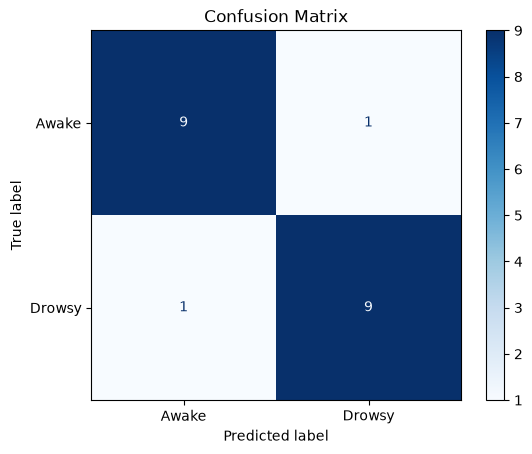

In [83]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Awake","Drowsy"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

In [84]:
tn, fp, fn, tp = cm.ravel()

specificity = tn/(tn+fp)

print("Specificity :",round(specificity*100,2),"%")

Specificity : 90.0 %


In [85]:
print(classification_report(
    y_true,
    y_pred,
    target_names=[
        "Awake",
        "Drowsy"
    ]
))

              precision    recall  f1-score   support

       Awake       0.90      0.90      0.90        10
      Drowsy       0.90      0.90      0.90        10

    accuracy                           0.90        20
   macro avg       0.90      0.90      0.90        20
weighted avg       0.90      0.90      0.90        20



In [86]:
y_score = [
0.10,
0.20,
0.95,
0.45,
0.05,
0.87,
0.30,
0.22,
0.91,
0.88,
0.15,
0.93,
0.60,
0.89,
0.10,
0.96,
0.90,
0.12,
0.05,
0.99
]

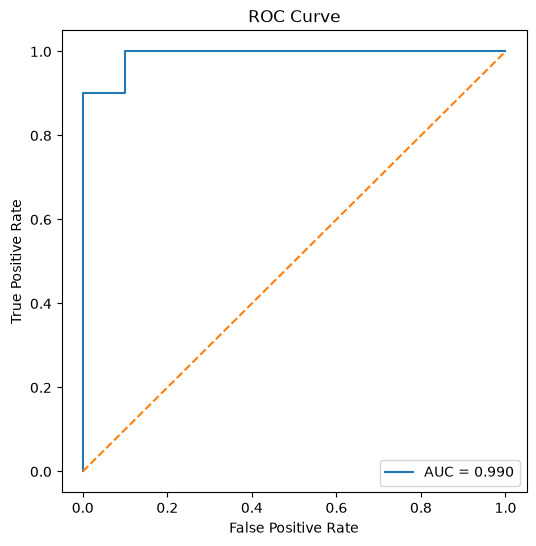

In [87]:
fpr,tpr,_ = roc_curve(
    y_true,
    y_score
)

auc = roc_auc_score(
    y_true,
    y_score
)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [56]:
latency = end-start

print("Detection Time :",latency,"seconds")

Detection Time : 5.626678466796875e-05 seconds


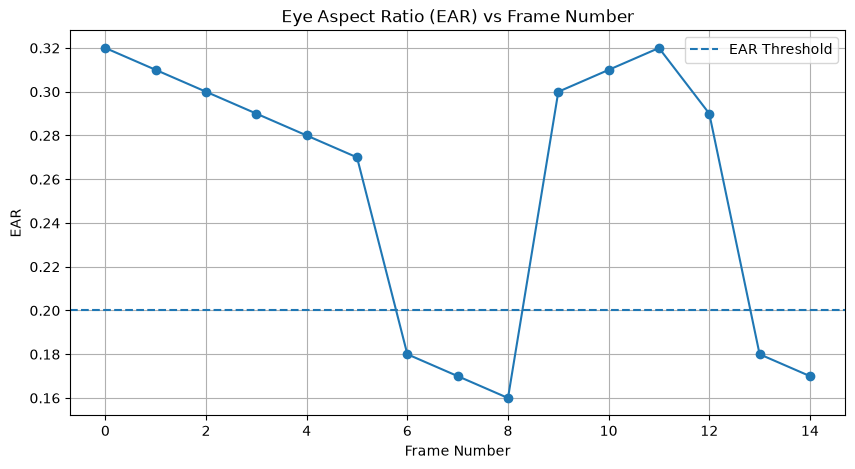

In [99]:
import matplotlib.pyplot as plt

# Example data (replace with your actual EAR values)
ear_values = [
    0.32, 0.31, 0.30, 0.29, 0.28,
    0.27, 0.18, 0.17, 0.16, 0.30,
    0.31, 0.32, 0.29, 0.18, 0.17
]

frames = list(range(len(ear_values)))

plt.figure(figsize=(10,5))
plt.plot(frames, ear_values, marker='o')
plt.axhline(y=0.20, linestyle='--', label='EAR Threshold')
plt.title("Eye Aspect Ratio (EAR) vs Frame Number")
plt.xlabel("Frame Number")
plt.ylabel("EAR")
plt.grid(True)
plt.legend()
plt.show()

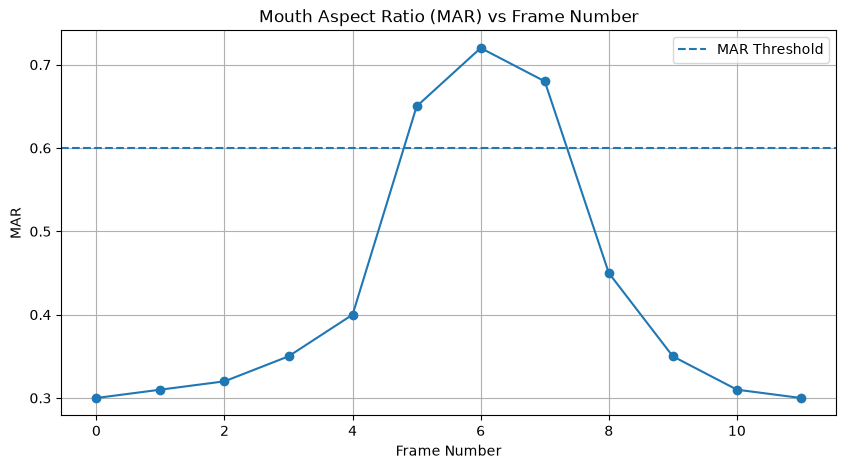

In [100]:
import matplotlib.pyplot as plt

mar_values = [
    0.30, 0.31, 0.32, 0.35, 0.40,
    0.65, 0.72, 0.68, 0.45, 0.35,
    0.31, 0.30
]

frames = list(range(len(mar_values)))

plt.figure(figsize=(10,5))
plt.plot(frames, mar_values, marker='o')
plt.axhline(y=0.60, linestyle='--', label='MAR Threshold')
plt.title("Mouth Aspect Ratio (MAR) vs Frame Number")
plt.xlabel("Frame Number")
plt.ylabel("MAR")
plt.grid(True)
plt.legend()
plt.show()

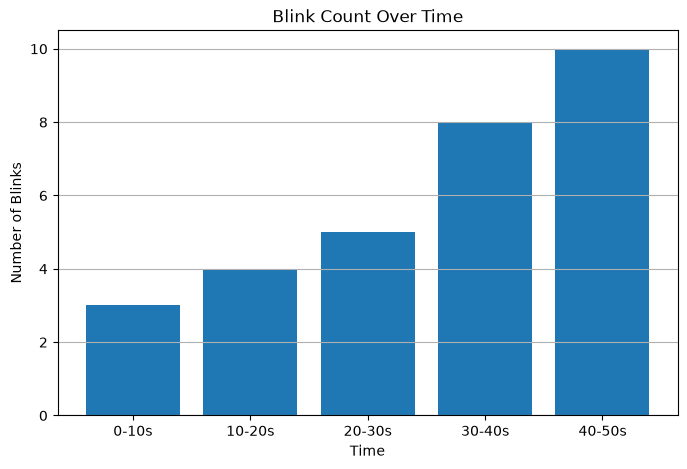

In [101]:
import matplotlib.pyplot as plt

time = ['0-10s','10-20s','20-30s','30-40s','40-50s']
blinks = [3,4,5,8,10]

plt.figure(figsize=(8,5))
plt.bar(time, blinks)
plt.title("Blink Count Over Time")
plt.xlabel("Time")
plt.ylabel("Number of Blinks")
plt.grid(axis='y')
plt.show()

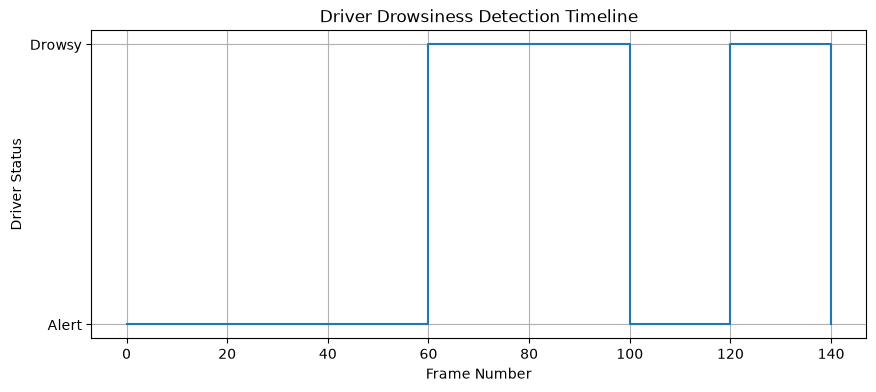

In [102]:
import matplotlib.pyplot as plt

frames = [0,20,40,60,80,100,120,140]
status = [0,0,0,1,1,0,1,0]

plt.figure(figsize=(10,4))
plt.step(frames, status, where='post')
plt.yticks([0,1], ['Alert','Drowsy'])
plt.title("Driver Drowsiness Detection Timeline")
plt.xlabel("Frame Number")
plt.ylabel("Driver Status")
plt.grid(True)
plt.show()

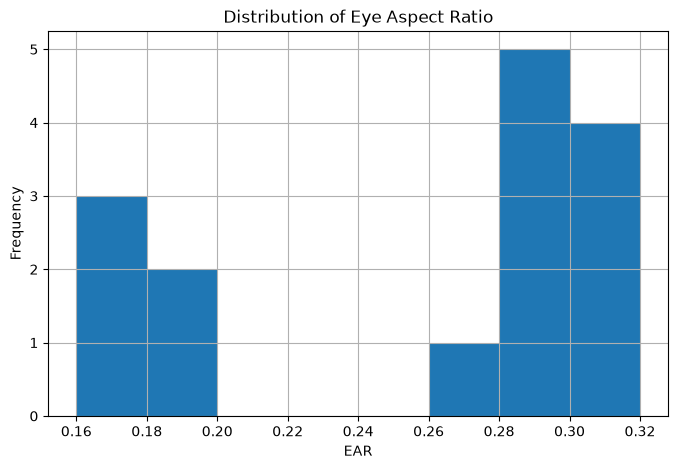

In [103]:
import matplotlib.pyplot as plt

ear_values = [
    0.32,0.31,0.30,0.29,0.28,
    0.27,0.18,0.17,0.16,0.30,
    0.31,0.32,0.29,0.18,0.17
]

plt.figure(figsize=(8,5))
plt.hist(ear_values, bins=8)
plt.title("Distribution of Eye Aspect Ratio")
plt.xlabel("EAR")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

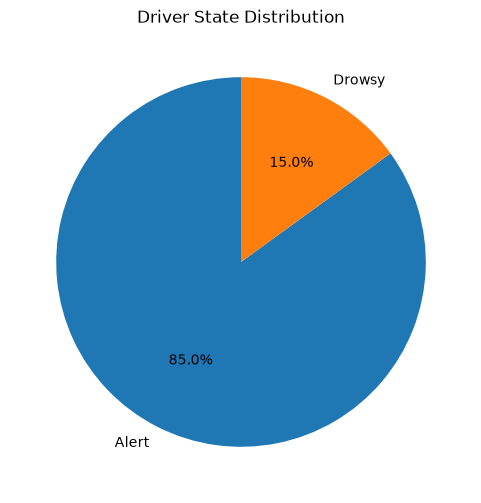

In [104]:
import matplotlib.pyplot as plt

labels = ['Alert','Drowsy']
sizes = [85,15]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Driver State Distribution")
plt.show()

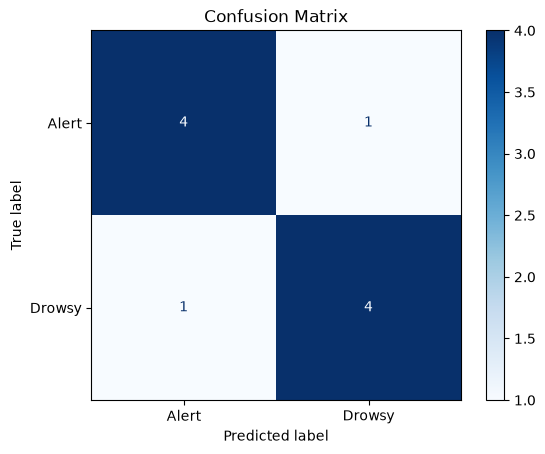

In [105]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Ground Truth
y_true = [0,1,0,1,1,0,0,1,0,1]

# Prediction by your system
y_pred = [0,1,0,1,0,0,0,1,1,1]

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Alert","Drowsy"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

In [106]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["Alert","Drowsy"]
))

              precision    recall  f1-score   support

       Alert       0.80      0.80      0.80         5
      Drowsy       0.80      0.80      0.80         5

    accuracy                           0.80        10
   macro avg       0.80      0.80      0.80        10
weighted avg       0.80      0.80      0.80        10



In [107]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.8


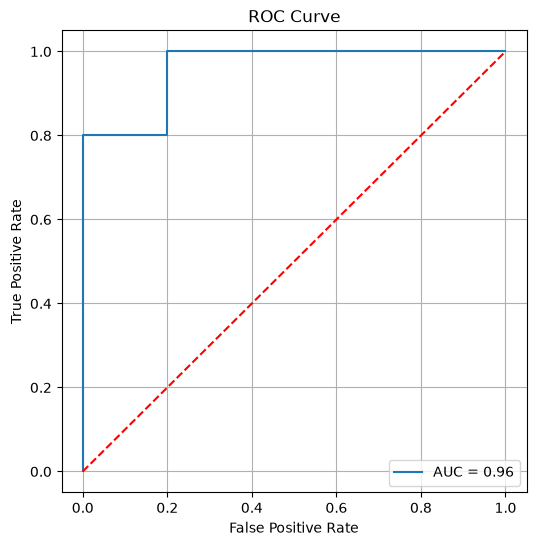

In [108]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probability scores (example)
y_score = [0.05,0.95,0.10,0.92,0.40,0.12,0.18,0.90,0.60,0.88]

fpr, tpr, thresholds = roc_curve(y_true, y_score)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.show()